0.Nível 1

Faça a conexão em Python com o MySQL Workbench para carregar todas as informações que você tem nas tabelas.

Você realizará uma visualização para cada exercício. Comente o que lhe chama a atenção na representação gráfica desta variável, justifique a escolha do gráfico e interprete os resultados com base nos seus dados.



pip install pandas
pip install matplotlib
python -m pip install --upgrade pip
python -m pip install ipykernel -U --force-reinstall
pip install numpy
pip install mysql-connector-python

después hice un bucle para crear mis dataframes


HE MODIFICADO UNA COLUMNA EM EL DATAFRAME DF_PRODUCTS ['PRICE']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import mysql.connector

connection = mysql.connector.connect(user='*', password='*',
                                      host='*',
                                      database='*')

cursor = connection.cursor()
cursor.execute("SHOW TABLES")

# Lista de todas as tabelas no banco de dados
tables = cursor.fetchall()

# Criar DataFrames dinamicamente com base nos nomes das tabelas
for table in tables:
    table_name = table[0]  # Nome da tabela (tuple, por isso usamos [0])
    query = f"SELECT * FROM {table_name}"
    df = pd.read_sql(query, connection)
    
    # Atribuir o DataFrame a uma variável com o nome da tabela
    globals()[f"df_{table_name}"] = df

# Fechar o cursor e a conexão
cursor.close()
connection.close()

# Mostrar os DataFrames criados
for table in tables:
    table_name = table[0]
    df = globals().get(f"df_{table_name}")
    print(f"\nDataFrame for table: {table_name}")
    print(df.head().to_string())


df_products['price'] = df_products['price'].str.replace('$', '', regex=False)
df_products['price'] = pd.to_numeric(df_products['price'])

# QUITAR EL SIMBOLO ($) Y DESPUES CONVERTILO EN FLOAT 

pd.options.mode.copy_on_write = True 


DataFrame for table: companies
  company_id                 company_name           phone                             email        country                         website
0     b-2222    Ac Fermentum Incorporated  06 85 56 52 33  donec.porttitor.tellus@yahoo.net        Germany      https://instagram.com/site
1     b-2226     Magna A Neque Industries  04 14 44 64 62       risus.donec.nibh@icloud.org      Australia    https://whatsapp.com/group/9
2     b-2230                  Fusce Corp.  08 14 97 58 85              risus@protonmail.edu  United States  https://pinterest.com/sub/cars
3     b-2234    Convallis In Incorporated  06 66 57 29 50                mauris.ut@aol.couk        Germany        https://cnn.com/user/110
4     b-2238  Ante Iaculis Nec Foundation  08 23 04 99 53       sed.dictum.proin@outlook.ca    New Zealand    https://netflix.com/settings

DataFrame for table: credit_cards
         id  user_id                          iban                 pan   pin  cvv                  

C:\Users\Lucan Vieira\AppData\Local\Temp\ipykernel_11620\2445782431.py:23: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.




- Exercício 1
Uma variável numérica.

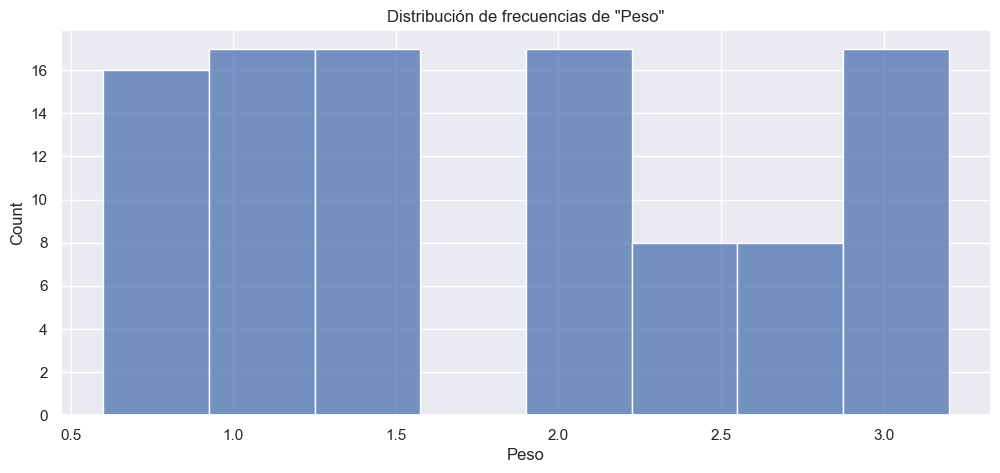

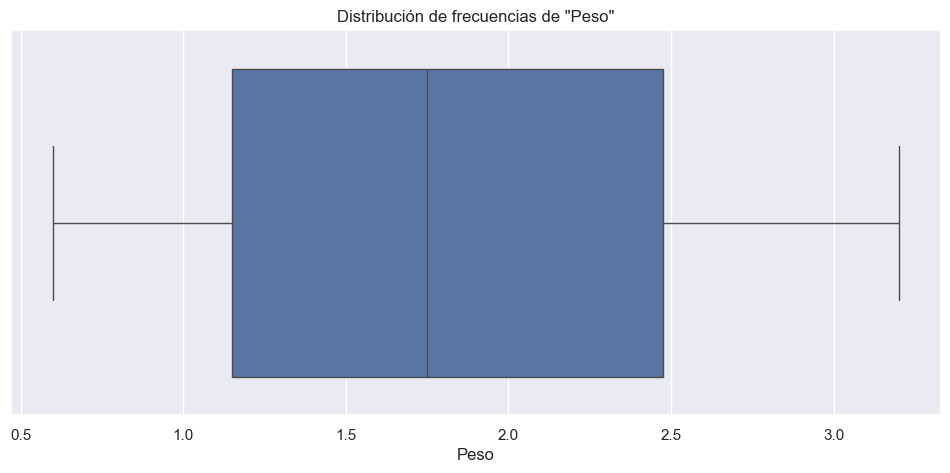

In [76]:
plt.figure(figsize=(12,5))
plt.title('Distribución de frecuencias de "Peso"')
sns.histplot(data=df_products, x="weight")
plt.xlabel('Peso')

plt.show()

plt.figure(figsize=(12,5))
plt.title('Distribución de frecuencias de "Peso"')
sns.boxplot(data=df_products, x="weight")
plt.xlabel('Peso')

plt.show()



# INTERPRETACIÓN DEL GRAFICO: 
El gráfico representa la distribución de frecuencias de PESO. Hay una pequeña tendencia a tener pesos mayores que 1.5 kg.


- Exercício 2
Duas variáveis ​​numéricas.

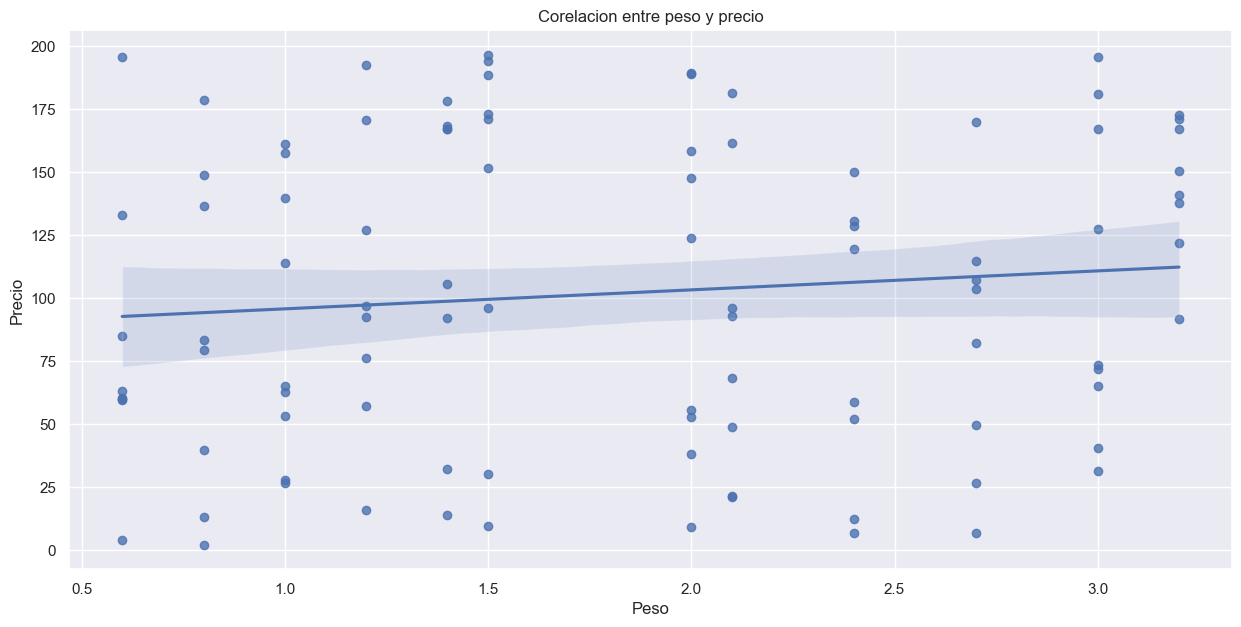

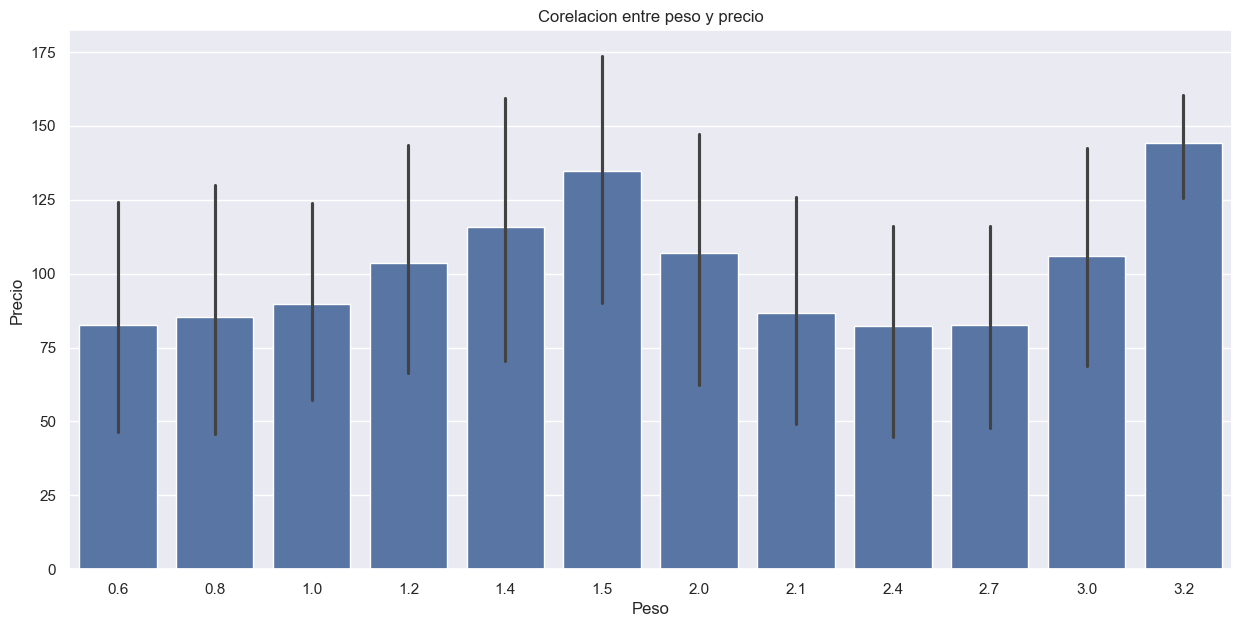

In [77]:
spearman_corr = df_products[['weight', 'price']]

sns.set_theme(style='darkgrid')
plt.figure(figsize=(15,7))
sns.regplot(data=df_products, x="weight", y='price')
plt.xlabel('Peso')
plt.ylabel('Precio')
plt.title(f'Corelacion entre peso y precio')
plt.show()




sns.set_theme(style='darkgrid')
plt.figure(figsize=(15, 7))
sns.barplot(data=df_products, x="weight", y="price")
plt.xlabel('Peso')
plt.ylabel('Precio')
plt.title(f'Corelacion entre peso y precio')
plt.show()





# INTERPRETACIÓN DEL GRAFICO: 
HAY una pequeña tendencia positiva: a medida que aumenta el peso, también lo hace el precio hasta el peso 2.0 en que esta tendencia cae y sigue cayendo hasta 2.7 volviendo a subir en el 3.0. No es una relacion de producto mas pesado igual a producto mas caro, sin embargo es un buen gráfico para equipos de logística.

- Exercício 3
Uma variável categórica.

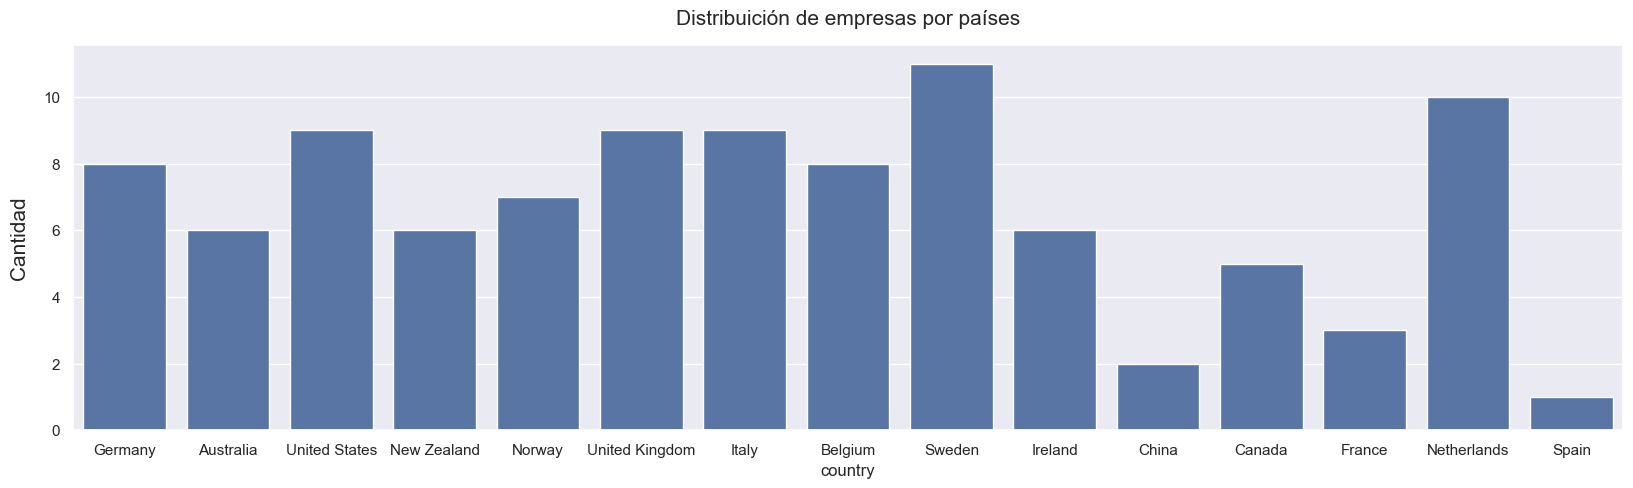

In [78]:
plt.figure(figsize=(20, 5)) 
sns.countplot(data=df_companies, x='country')
plt.title('Distribuición de empresas por países', fontsize=15, pad=15)
plt.ylabel('Cantidad', fontsize=15, labelpad=10)
plt.show()




# INTERPRETACIÓN DEL GRAFICO: 

El gráfico muestra la distribución de empresas según su país, utilizando un gráfico de barras. Su propósito es comparar la cantidad de empresas registradas en cada país. Se nota que hay una cantidad más grande en Sweeden y Netherlands y bajissima en Spain y China. Con este gráfico és posible mirar las cantidades y atraves de ellas entender (con otros graficos) si hay la necesidade de expansión de empresas en otros países. Yo haría la sugetión de investigar igual las ventas.


- Exercício 4
Uma variável categórica e uma variável numérica.

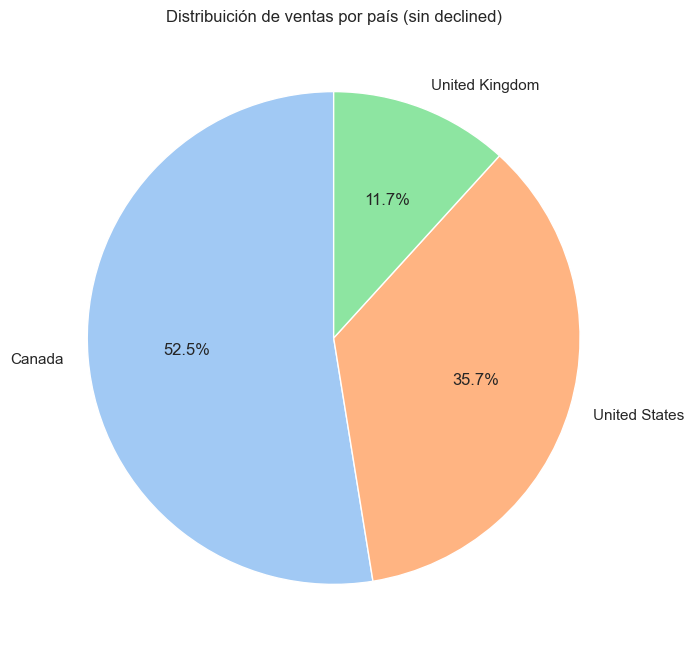

In [79]:
df_join_trans_user = pd.merge(df_transactions, df_users, left_on='user_id', right_on='id', how='outer')
df_filtered = df_join_trans_user[df_join_trans_user['declined'] != 1]


df_country_amount = df_filtered.groupby('country')['amount'].sum().reset_index()
df_country_amount_sorted = df_country_amount.sort_values(by='amount', ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(df_country_amount_sorted['amount'], labels=df_country_amount_sorted['country'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribuición de ventas por país (sin declined)')
plt.show()




# INTERPRETACIÓN DEL GRAFICO: 

Este es un grafico de pizza que hace una lectura de las ventas y su concentracón en Canadá, USA y UK. En en gráfico vizualizamos que la más grande concentración está en Canadá y más baja en UK.
UK és un mercado crítico; de hecho recomendaría priorizar inversiones en marketing, soporte o expansión en esta region;

ps. Exclusión de "declined": El filtro asegura que los datos reflejen solo transacciones exitosas.

- Exercício 5
Duas variáveis ​​categóricas.

In [80]:
df_us_tr = pd.merge(df_users, df_transactions, left_on='id', right_on='user_id', how='outer')
df_total = df_us_tr.groupby(['country', 'city'])['amount'].sum().reset_index()


fig = px.treemap(df_total,
                 path=['country', 'city'],  
                 values='amount',
                 color='amount',
                 color_continuous_scale='Viridis',
                 title='Gastos totales por país e cidade')
fig.show()

<Figure size 1200x800 with 0 Axes>

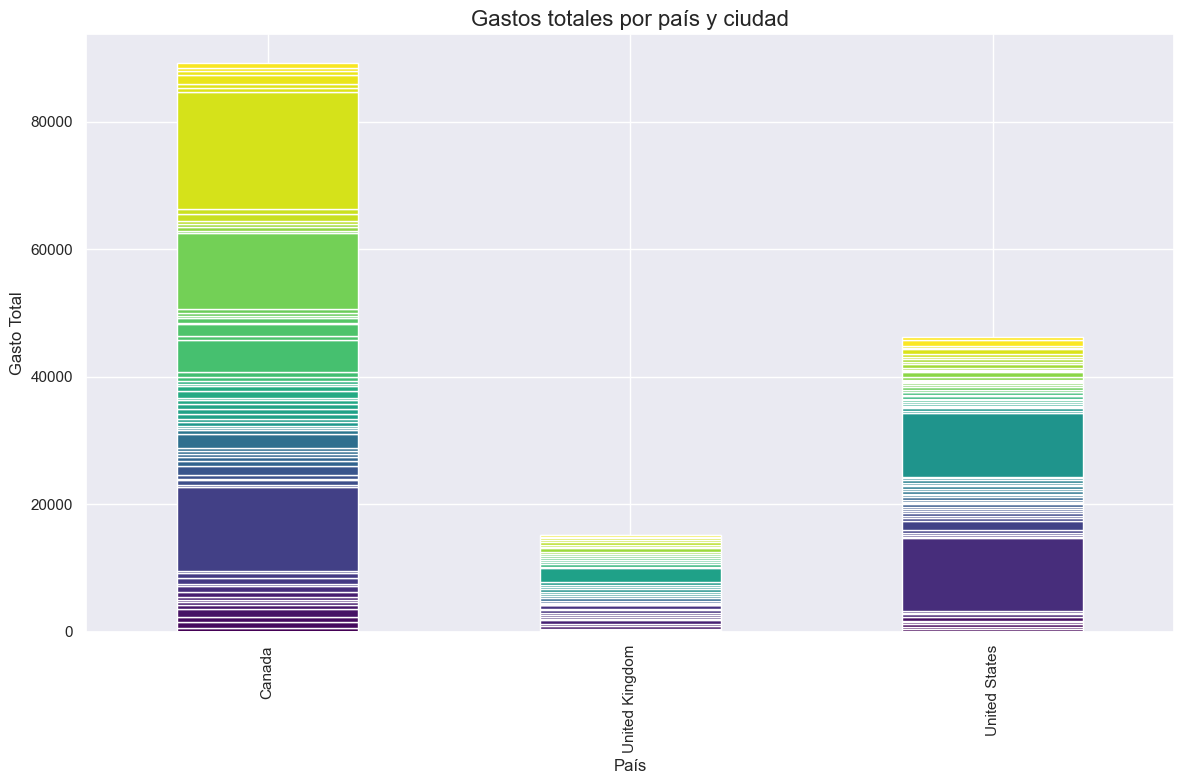

In [81]:
df_us_tr = pd.merge(df_users, df_transactions, left_on='id', right_on='user_id', how='outer')
df_total = df_us_tr.groupby(['country', 'city'])['amount'].sum().reset_index()

df_pivot = df_total.pivot_table(index='country', columns='city', values='amount', aggfunc='sum', fill_value=0)

plt.figure(figsize=(12, 8))
df_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')

plt.title('Gastos totales por país y ciudad', fontsize=16)
plt.xlabel('País', fontsize=12)
plt.ylabel('Gasto Total', fontsize=12)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()


# INTERPRETACIÓN DEL GRAFICO: 

Este análisis combina un gráfico de barras y un treemap para evaluar la distribución y concentración de ventas por ciudad. Los gráficos no representan todas las ciudades, sino que destacan aquellas con mayor participación en el volumen total de ventas, una decisión acertada dada la extensa cantidad de datos.

La elección de ambas visualizaciones es efectiva porque:
El gráfico de barras ofrece una comparación directa y cuantitativa del desempeño de cada ciudad; El treemap, por su parte, no solo refuerza la jerarquía de ventas, sino que también permite identificar patrones geográficos y concentraciones clave.

Esta dualidad enriquece el análisis, facilitando una comprensión más intuitiva y detallada de los datos.

- Exercício 6
Três variáveis.

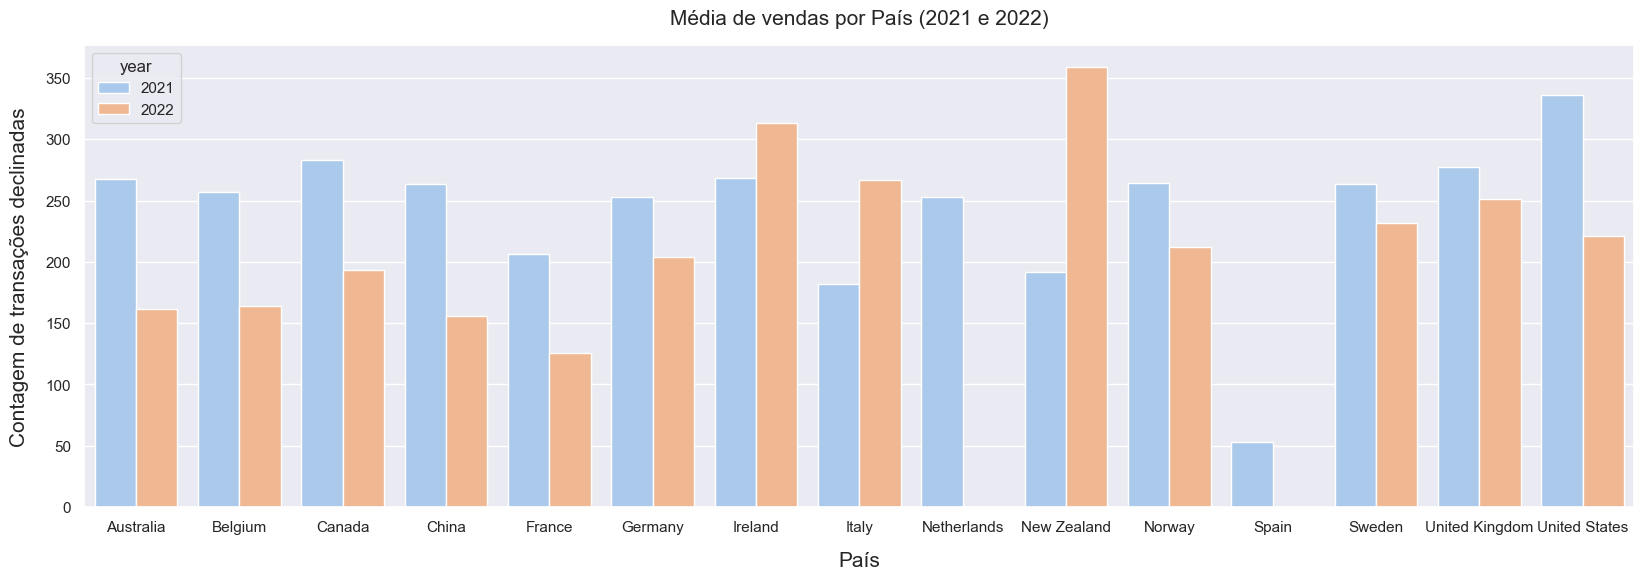

In [82]:
df_tran_comp = pd.merge(df_transactions, df_companies, left_on='business_id', right_on='company_id', how='outer')

df_seleccion = df_tran_comp[['country', 'timestamp', 'declined', 'amount']]

df_seleccion['year'] = df_seleccion['timestamp'].dt.year

df_filtered = df_seleccion[df_seleccion['year'].isin([2021, 2022])]

df_tc = df_filtered.groupby(['country', 'year'])['amount'].mean().reset_index()


plt.figure(figsize=(20, 6))
sns.barplot(data=df_tc, x='country', y='amount', hue='year', palette='pastel')
sns.set_theme(style='darkgrid')
plt.title('Média de vendas por País (2021 e 2022)', fontsize=15, pad=15)
plt.xlabel('País', fontsize=15, labelpad=12)
plt.ylabel('Contagem de transações declinadas', fontsize=15, labelpad=12)



plt.show()


# INTERPRETACIÓN DEL GRAFICO: 

Análisis de Datos: Media de Ventas por País (2021-2022)  

Cobertura Geográfica
El gráfico incluye 14 países, principalmente economías desarrolladas de Europa (Bélgica, Francia, Alemania, Irlanda, Italia, Países Bajos, España, Suecia, Reino Unido), América del Norte (Canadá, EE.UU.), Asia-Pacífico (Australia, Nueva Zelanda, China) y Noruega; China es el único representante asiático, lo que sugiere un enfoque en mercados con mayor poder adquisitivo.

Tendencias de Ventas
Países con Crecimiento Destacado
Irlanda, Nueva Zelanda e Italia muestran un crecimiento significativo en ventas. Irlanda, en particular, se destaca no solo por su alto volumen, sino también por su tendencia positiva. Mi Recomendación és Analizar las estrategias comerciales en Irlanda para replicar su éxito en otros mercados.

Países Clave con Oportunidades
Francia tiene un desempeño abajo de la media y decaió mucho, pero es relevante en terminos de geografia, asì que requiere atención estratégica para consolidar su crecimiento.


Diferencias por Región e Idioma
Las campañas publicitarias parecen tener mayor impacto en países de habla inglesa
Países no angloparlantes (Francia, España, Alemania) podrían requerir una mejor adaptación lingüística y cultural en las estrategias de marketing.


Acciones Recomendadas:
Enfocar esfuerzos en Irlanda como mercado prioritario, analizando los factores detrás de su éxito.




- Exercício 7
Crie um gráfico de Pairplot.

<Figure size 2000x2000 with 0 Axes>

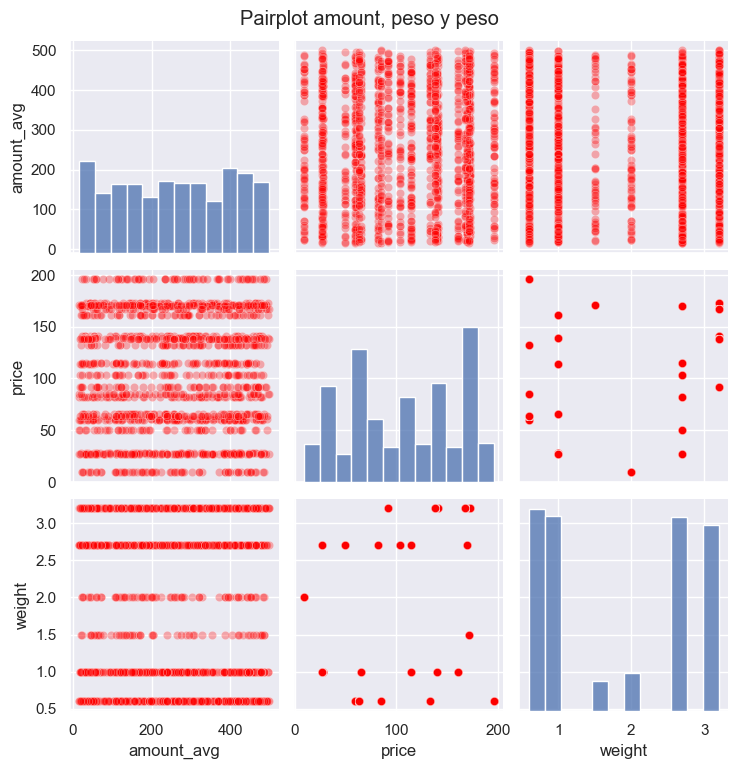

In [83]:
df_j_p_tp = pd.merge(df_transactions, df_transactions_products, left_on='id', right_on='transaction_id', how='outer')
df_j_ppp_ttt = pd.merge(df_j_p_tp, df_products, left_on='product_id', right_on='id', how='outer')

amount_avg = (
    df_j_ppp_ttt.groupby('transaction_id')['amount'].sum() / 
    df_j_ppp_ttt['transaction_id'].value_counts()
).rename('amount_avg')

df_j_ppp_ttt['amount_avg'] = df_j_ppp_ttt['transaction_id'].map(amount_avg)

df_pairplot = df_j_ppp_ttt[['amount_avg', 'price', 'weight']].dropna()

# Plotar
plt.figure(figsize=(20, 20)) 
sns.pairplot(df_pairplot, plot_kws={'color': 'red', 'alpha': 0.3})

plt.suptitle('Pairplot amount, peso y peso', y=1.02)
plt.show()


Nível 2


Exercício 1
Correlação de todas as variáveis ​​numéricas.

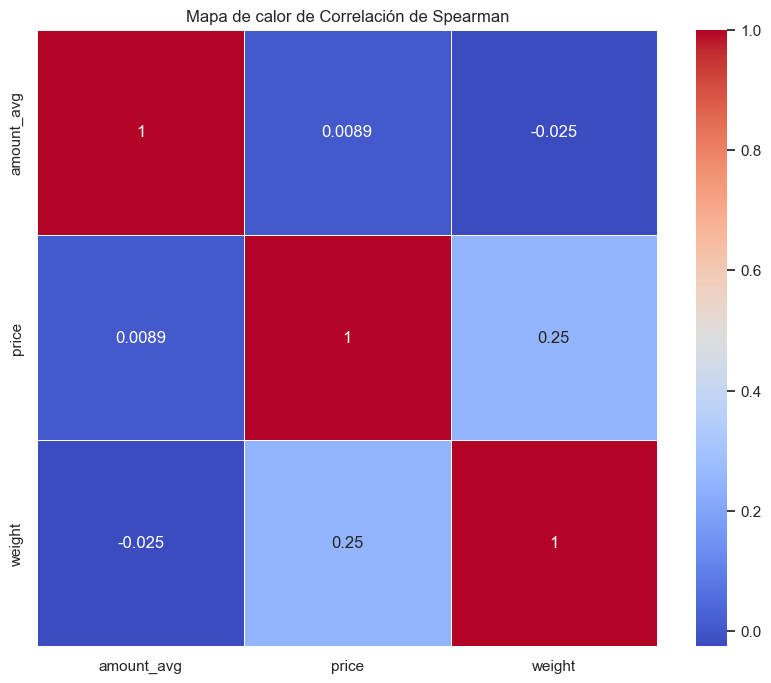

,amount_avg,price,weight
amount_avg,1.000000,0.008881,-0.024555
price,0.008881,1.000000,0.248283
weight,-0.024555,0.248283,1.000000


In [84]:
corr_num = df_pairplot.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de calor de Correlación de Spearman')
plt.show()

corr_num



In [85]:
df_pairplot.corr()

,amount_avg,price,weight
amount_avg,1.000000,0.011335,-0.014904
price,0.011335,1.000000,0.194816
weight,-0.014904,0.194816,1.000000


# INTERPRETACIÓN DEL GRAFICO: 

La utilizacion de Perason se da principalmente porque se nota mejor los datos en la tabla, los datos aparecen sin el method casi que no aparecen relaciones y se nota mucho el cambio de uno para el otro. Si notamos precio y peso hay un cambio de 5 puntos, por ejemplo. 



Exercício 2
Implementar um jointplot.

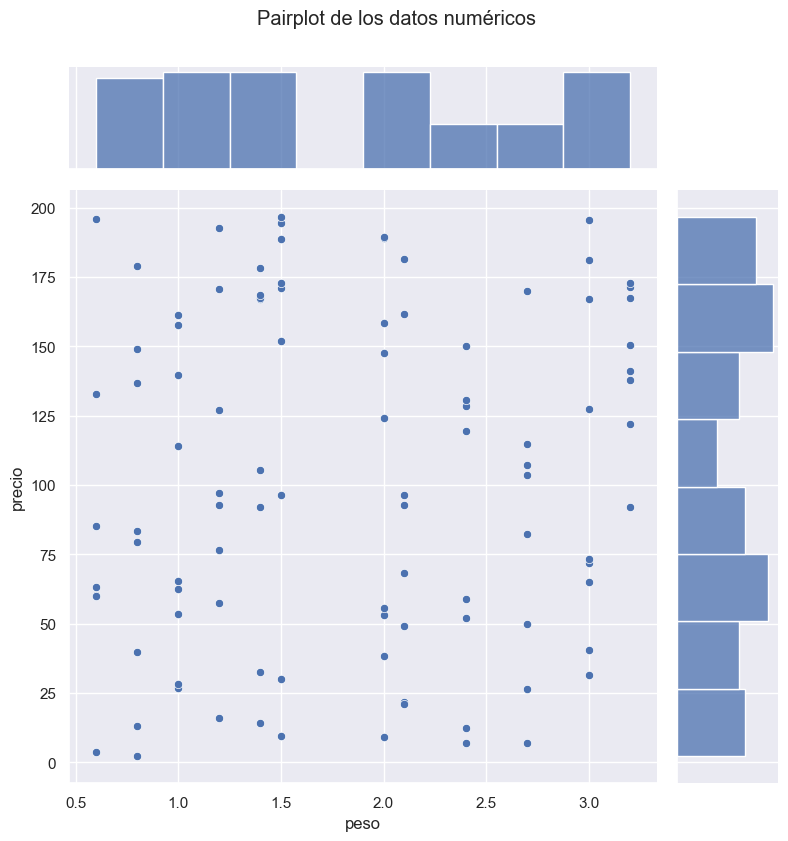

In [86]:
sns.jointplot(data=df_products, x='weight', y='price', height=8)

plt.suptitle('Pairplot de los datos numéricos', y=1.05)
plt.xlabel('peso')
plt.ylabel('precio')
plt.show()

# INTERPRETACIÓN DEL GRAFICO: 

sigue la misma interpretacion del ejercicio 2 nivel 1.

Nível 3



Exercício 1
Implemente um violinplot combinado com outro tipo de gráfico.


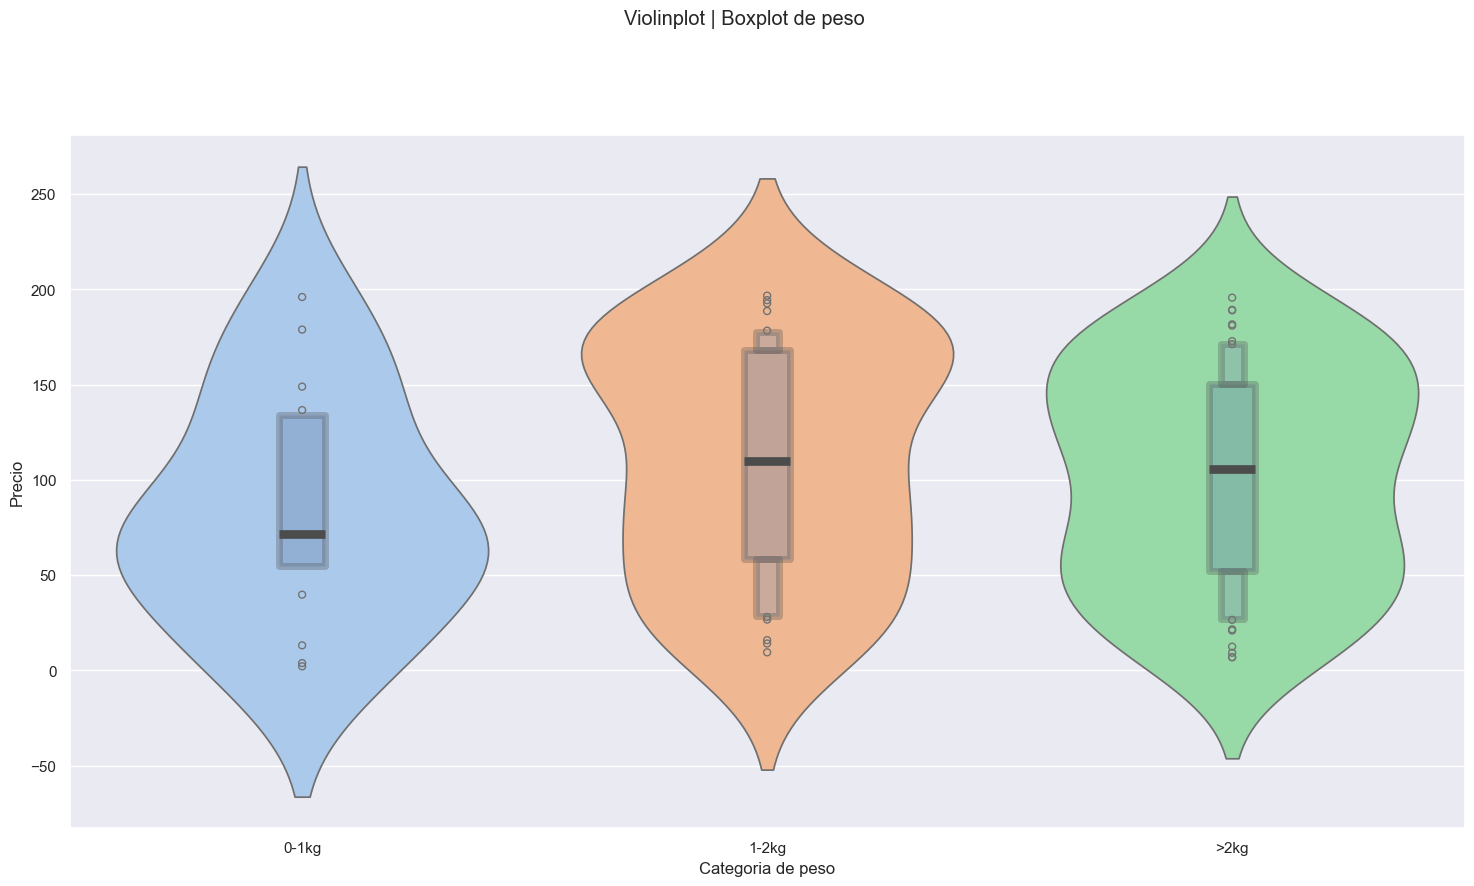

In [87]:
df_peso = df_products.dropna(subset=['weight'])


categoria_de_peso = []

for weight in df_peso['weight']:
    if weight < 1:
        categoria_de_peso.append('0-1kg')
    elif 1 <= weight < 2:
        categoria_de_peso.append('1-2kg')
    elif weight >= 2:
        categoria_de_peso.append('>2kg')

df_peso.loc[:,'categoria_de_peso'] = pd.Categorical(categoria_de_peso, categories=['0-1kg', '1-2kg', '>2kg'], ordered=True)

plt.figure(figsize=(18, 9)) 

p = (sns.violinplot(x='categoria_de_peso', y='price', data=df_peso, density_norm='count', width=0.8, hue='categoria_de_peso',palette='pastel', inner=None))

sns.boxenplot(x='categoria_de_peso', y='price', data=df_peso, width=0.1, linewidth=5, alpha=0.3)
p.set(xlabel='Categoria de peso', ylabel='Precio' )

plt.suptitle('Violinplot | Boxplot de peso', y=1.02)

plt.show()


# INTERPRETACIÓN DEL GRAFICO: 

seguiria la misma interpretacion del ejercicio 2 nivel 1, pero la diferencia es que he hecho la categorizacion de los datos en tres categorias;


Exercício 2
Gera um FacetGrid para visualizar vários aspectos dos dados simultaneamente.

<Figure size 1800x900 with 0 Axes>

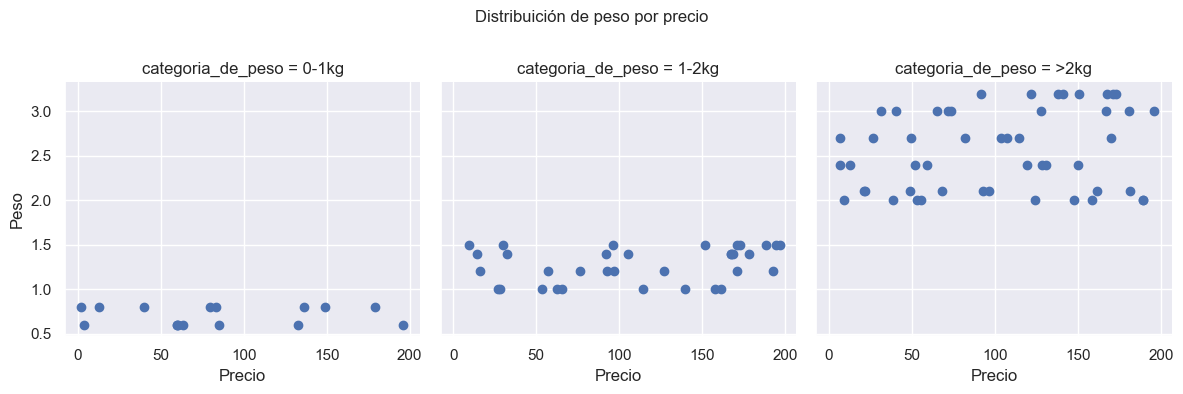

In [88]:
plt.figure(figsize=(18, 9)) 
g = sns.FacetGrid(df_peso, col='categoria_de_peso', height=4,aspect=1)
g.map(plt.scatter, 'price', 'weight')
 
g.fig.suptitle("Distribuición de peso por precio", fontsize=12)
g.fig.subplots_adjust(top=0.80)
g.set_axis_labels('Precio', 'Peso')

plt.show()


# INTERPRETACIÓN DEL GRAFICO: 